<a href="https://colab.research.google.com/github/Liping-LZ/BDAO_DSDO_2425/blob/main/Big_data_analytics/NLP/Natural_language_processing_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. What is Natural Language Processing (NLP)**

Natural Language Processing (NLP) is broadly defined as the automatic manipulation of natural language, like speech and text, by software. In other words, NLP is an important technique to help understand human language. NLP is a broad topic but we are mainly talking about how to use NLP techniques to do text mining and text analysis. In this tutorial, we will talk about text cleaning and data text processing, which are the essential steps to get data prepared for further text mining.



# **2. Text pre-processing**
Usually, we need to do some proper text cleanning and processing before text mining (e.g. topic modeling).

Here are the common steps to follow:

#### **Step 1: Cleaning text**
- (optional) Encoding. Usually you don't need to set up the encoding type or just set it as "utf-8" (which is suitable for all languages), but sometimes if your text data is non-English, you might need to look for the right encoding type. For example, "latin_1" is suitable for the languages in Western Europe and "gbk" for Chinese. Here is the [List of Python standard encodings](https://docs.python.org/3/library/codecs.html#standard-encodings).
- Lower casing;
- Remove contractions;
- Remove numbers;
- Remove email address and url;
- Remove special characters, such as emoji;
- Remove punctuation;
- Remove extra space

And more...

In [ ]:
text = "BDAO github repository https://github.com/Liping-LZ/BDAO_DSDO_2425/ is 🔥🔥 Coding is SUPER fun!!! Hope I'll do it again. By the way Mark is the best 1234. my email: liping@gmail.com"

In [ ]:
# Lower casing
new = text.lower()
new

"bdao github repository https://github.com/liping-lz/bdao_dsdo_2425/ is 🔥🔥 coding is super fun!!! hope i'll do it again. by the way mark is the best 1234. my email: liping@gmail.com"

In [ ]:
# Remove contractions
!pip install contractions
import contractions
new = contractions.fix(new)
new

'bdao github repository https://github.com/liping-lz/bdao_dsdo_2425/ is 🔥🔥 coding is super fun!!! hope i will do it again. by the way mark is the best 1234. my email: liping@gmail.com'

In [ ]:
# remove numbers
new = re.sub(r"\d+", "", new)
new

'bdao github repository https://github.com/liping-lz/bdao_dsdo_/ is 🔥🔥 coding is super fun!!! hope i will do it again. by the way mark is the best . my email: liping@gmail.com'

In [ ]:
# Remove urls
new = re.sub('http://\S+|https://\S+', '', new)
new

'bdao github repository  is 🔥🔥 coding is super fun!!! hope i will do it again. by the way mark is the best . my email: liping@gmail.com'

In [ ]:
# Remove email address or @mentions
new = re.sub('\S*@\S*\s?', '', new)
new

'bdao github repository  is 🔥🔥 coding is super fun!!! hope i will do it again. by the way mark is the best . my email: '

In [ ]:
# Remove emoji & emoticons
# First, build a list of commonly used emojis
# emoji/emoticons dictionary here: https://github.com/NeelShah18/emot/blob/master/emot/emo_unicode.py
import re
emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"

                      "]+", re.UNICODE)

new = re.sub(emoj, '', new)
new

'bdao github repository  is  coding is super fun!!! hope i will do it again. by the way mark is the best . my email: '

In [ ]:
# Remove punctuation
import string
import re
new = re.sub('[%s]' % re.escape(string.punctuation), ' ', new)
new

'bdao github repository  is  coding is super fun    hope i will do it again  by the way mark is the best   my email  '

In [ ]:
# Remove extra space
new = re.sub('\s{2,}', ' ', new)
new

'bdao github repository is coding is super fun hope i will do it again by the way mark is the best my email '

#### **Step 2: Tokenisation**
In this step, the text is split into smaller units. Sentence-->words.

In [ ]:
import nltk
nltk.download('punkt_tab')

# tokenise the words
from nltk.tokenize import word_tokenize
word_token = word_tokenize(new)

word_token

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['bdao',
 'github',
 'repository',
 'is',
 'coding',
 'is',
 'super',
 'fun',
 'hope',
 'i',
 'will',
 'do',
 'it',
 'again',
 'by',
 'the',
 'way',
 'mark',
 'is',
 'the',
 'best',
 'my',
 'email']

#### **Step 3: Remove stop words**
stop words are a set of commonly used words in a language. Example of stop words in English are "is", "a", "the" and etc. These words are usually not useful, so we normally remove them.

In [ ]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
# use English stopwords
stopwords = stopwords.words("english")
stopwords.extend(['app']) #add more stopwords here
token_without_stopwords = [w for w in word_token if not w in stopwords]
token_without_stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['bdao',
 'github',
 'repository',
 'coding',
 'super',
 'fun',
 'hope',
 'way',
 'mark',
 'best',
 'email']

#### **Step 4: Stemming or Lemmatisation**
Stemming is the text standardization step where the words are stemmed or diminished to their root/base form. For example, words like ‘programmer’, ‘programming, ‘program’ will be stemmed to ‘program’. But the disadvantage of stemming is that it stems the words such that its root form loses the meaning or it is not diminished to a proper English word. For example, "manages" will be stemmed to "manag".

Lemmatisation also stems the words but try to make sure the words are not losing their meaning.Lemmatization has a pre-defined dictionary that stores the context of words and checks the word in the dictionary while diminishing. Thus, the words make more sense in this case, but lemmatisation might take longer to run.

We don't need to use both, but which one to choose? It depends. Sometimes stemming works fine then it's more effective. But if we need to get the actual meaning with actual words, then lemmatisation is more suitable.

In [ ]:
# Stemming
from nltk.stem import PorterStemmer
ps = PorterStemmer()

text = ['managers', 'managing', 'management', 'manage','manages','managed']
stemmed = [ps.stem(w) for w in text]
stemmed

['manag', 'manag', 'manag', 'manag', 'manag', 'manag']

In [ ]:
# Lemmatisation using spaCy
import spacy

# Load the spaCy model
nlp = spacy.load("en_core_web_sm")

# Process the text with spaCy
doc = nlp(" ".join(text))

# Do lemmatisation
data_lemmatised = [w.lemma_ for w in doc]
# data_lemmatised = [w.lemma_ for w in doc if w.pos_ in ['NOUN', 'ADJ', 'VERB', 'ADV']]
data_lemmatised

['manager', 'manage', 'management', 'manage', 'manage', 'manage']

In [ ]:
# Lemmatisation using nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

n_lemmatised = [lemmatizer.lemmatize(w) for w in text]
v_lemmatised = [lemmatizer.lemmatize(w,'v') for w in n_lemmatised]
r_lemmatised = [lemmatizer.lemmatize(w,'r') for w in v_lemmatised]
a_lemmatised = [lemmatizer.lemmatize(w,'a') for w in r_lemmatised]

a_lemmatised

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


['manager', 'manage', 'management', 'manage', 'manage', 'manage']

In [ ]:
# Stemming
from nltk.stem import PorterStemmer
ps = PorterStemmer()

token_stemmed = [ps.stem(w) for w in token_without_stopwords]
token_stemmed

['bdao',
 'github',
 'repositori',
 'code',
 'super',
 'fun',
 'hope',
 'way',
 'mark',
 'best',
 'email']

In [ ]:
# Lemmatisation using spaCy
import spacy

# Load the spaCy model
nlp = spacy.load("en_core_web_sm")

# Process the text with spaCy
doc = nlp(" ".join(token_without_stopwords))

# Do lemmatisation keeping only noun, adj, vb, adv
token_lemmatised = [w.lemma_ for w in doc]
token_lemmatised

['bdao',
 'github',
 'repository',
 'code',
 'super',
 'fun',
 'hope',
 'way',
 'mark',
 'good',
 'email']

#### **Step 5: Once the processing are done, put the tokens back together as text**

In [ ]:
# put the tokens back together as text after stemming
new_text = " ".join(token_stemmed)
new_text

'bdao github repositori code super fun hope way mark best email'

In [ ]:
# put the tokens back together as text after stemming
new_text = " ".join(token_lemmatised)
new_text

'bdao github repository code super fun hope way mark good email'

#### **Let's put all steps together to pre-process multiple texts**

In [ ]:
# Let's import data first
# Run the code and upload the csv file from your laptop
from google.colab import files
uploaded = files.upload()

Saving british_airways_reviews.csv to british_airways_reviews.csv


In [ ]:
import pandas as pd

data = 'british_airways_reviews.csv' # change the csv file name to your file name that you uploaded
df = pd.read_csv(data)
df.head()

,title,reviews,published_dates,user_name,user_location,user_ratings,trip_details,would_recommed_to_others
0,“Worst service ever”,Worst service ever. Lost baggage because of d...,23rd January 2024,Chirag Thummar,Germany,1,Type Of TravellerSolo Leisure\nSeat TypeEconom...,n
1,"""unprofessional attitude of the pilots""",BA 246 21JAN 2023 Did not appreciate the unp...,21st January 2024,D Carreno,United Kingdom,6,AircraftA350\nType Of TravellerBusiness\nSeat ...,n
2,“Next time it will be Jet2”,Not a great experience. I could not check in ...,18th January 2024,Simon Channon,United Kingdom,3,AircraftA320\nType Of TravellerCouple Leisure\...,n
3,“become the Ryanair of long-haul travel”,I was excited to fly BA as I'd not travelled ...,18th January 2024,Melissa Harris,United Kingdom,2,Type Of TravellerFamily Leisure\nSeat TypeEcon...,n
4,“They never help us”,I just want to warn everyone of the worst cu...,17th January 2024,Ivana Squassabia,Germany,1,Type Of TravellerFamily Leisure\nSeat TypeBusi...,n


In [ ]:
target_column = 'reviews'

In [ ]:
# Text cleaning
!pip install contractions
import re
import string
import contractions

# drop data with missing values in the target' column
df = df.dropna(subset=[target_column])

# drop duplicate review content
df = df.drop_duplicates(subset=[target_column])

# remove contraction
df[target_column] = df[target_column].map(lambda x: contractions.fix(x))

# convert the relevant column to lowercase
df[target_column] = df[target_column].str.lower()

# Remove non-word characters, so numbers and ___ etc
df[target_column] = df[target_column].str.replace("[^A-Za-z]", " ", regex = True)

# Remove url link
df[target_column] = df[target_column].apply(lambda x: re.sub('http://\S+|https://\S+', '', x))

# Remove email address
df[target_column] = df[target_column].map(lambda x: re.sub('\S*@\S*\s?', '', x))

# Remove emoji
emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"

                      "]+", re.UNICODE)

df[target_column] = df[target_column].map(lambda x: re.sub(emoj, '', x))

# Remove punctuation
df[target_column] = df[target_column].map(lambda x: re.sub('[%s]' % re.escape(string.punctuation), ' ', x))

# Remove overspace
df[target_column] = df[target_column].map(lambda x: re.sub('\s{2,}', " ", x))

In [ ]:
# Text transformation
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import spacy

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# create a list of the contents from the target column
words = df[target_column].tolist()

# tokenise the words
word_tokens = []
for content in words:
    word_tokens.append(word_tokenize(content))

# remove stop words
stop_words = stopwords.words('english')
stop_words.extend(['flight','british','airway']) #add more stopwords here
tokens_without_stopwords = [] # create a new list with stop words removed
for review in word_tokens:
    tokens_without_stopwords.append([w for w in review if not w in stop_words])


# lemmatisation
nlp = spacy.load("en_core_web_sm") # Load the spaCy model

data_lemmatised = []
for review in tokens_without_stopwords:
    doc = nlp(" ".join(review)) # Process the text with spaCy
    data_lemmatised.append([w.lemma_ for w in doc if w.pos_ in ['NOUN', 'ADJ', 'VERB', 'ADV']]) # keeping only noun, adj, vb, adv

rejoin = []
for content in data_lemmatised:
    x = " ".join(content) # join the text back together
    rejoin.append(x)

# add the reformed text to the data frame
df['cleaned_review'] = rejoin

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
df.head()

,title,reviews,published_dates,user_name,user_location,user_ratings,trip_details,would_recommed_to_others,cleaned_review
0,“Worst service ever”,worst service ever lost baggage because of de...,23rd January 2024,Chirag Thummar,Germany,1,Type Of TravellerSolo Leisure\nSeat TypeEconom...,n,bad service ever lose baggage delay miss conne...
1,"""unprofessional attitude of the pilots""",ba jan did not appreciate the unprofessional ...,21st January 2024,D Carreno,United Kingdom,6,AircraftA350\nType Of TravellerBusiness\nSeat ...,n,appreciate unprofessional attitude pilot sched...
2,“Next time it will be Jet2”,not a great experience i could not check in o...,18th January 2024,Simon Channon,United Kingdom,3,AircraftA320\nType Of TravellerCouple Leisure\...,n,great experience check online separate part co...
3,“become the Ryanair of long-haul travel”,i was excited to fly ba as i would not travel...,18th January 2024,Melissa Harris,United Kingdom,2,Type Of TravellerFamily Leisure\nSeat TypeEcon...,n,excited fly ba travel long travel many occasio...
4,“They never help us”,i just want to warn everyone of the worst cus...,17th January 2024,Ivana Squassabia,Germany,1,Type Of TravellerFamily Leisure\nSeat TypeBusi...,n,want warn bad customer service experience ever...


# **3. Text vectorisation**

Text Vectorisation is the process of converting text into numerical representation. Once we convert text into numbers, then they can be usable features to be put into models. And with numbers we can do more further analysis and interpretation of the data as well.

Here we are introducing two methods of verctorisation:
- Term Document Matrix: create a binary vector where each index denotes the presence or absence of a word;
- Term Frequency-Inverse Document Frequency: weight each word by some form of importance score as well when creating term document matrix.

In [ ]:
# For creating Term Document Matrix (DTM), CountVectorizer() from scikit-learn
from sklearn.feature_extraction.text import CountVectorizer

# set vectorizer - CountVectorizer for word counts
vectorizer = CountVectorizer()

# create an array of word counts
doc_vec = vectorizer.fit_transform(df.cleaned_review)

# convert this to a dataframe
dtm = pd.DataFrame(doc_vec.toarray(), columns=vectorizer.get_feature_names_out())

# set a threshold to drop infrequent words. here we set overall mean as the threshold. you can change the threshold to control the number of terms
threshold = dtm.mean().mean()

# drop words based on the threshold
dtm = dtm.drop(dtm.mean()[dtm.mean() < threshold].index.values, axis=1) # Here find out the word with average word count lower than the threshold and drop them

# join the two datasets together
# dtm = df.join(dtm, how='left')
dtm.head()

,able,absolutely,accept,acceptable,access,accommodation,account,actually,add,additional,...,word,work,world,worst,worth,write,wrong,year,yet,young
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
4,0,2,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# create a list of words sorted by counts descending
word_freq = dtm.sum(axis=0)
word_freq_df = pd.DataFrame({'word': word_freq.index, 'count': word_freq.values})
word_freq_df = word_freq_df.sort_values(by='count', ascending=False)
word_freq_df.head(10) # change number in head() to control the top n

,word,count
678,seat,1322
691,service,999
785,time,787
373,hour,724
336,get,721
342,good,647
189,crew,633
315,food,628
312,fly,626
136,check,569


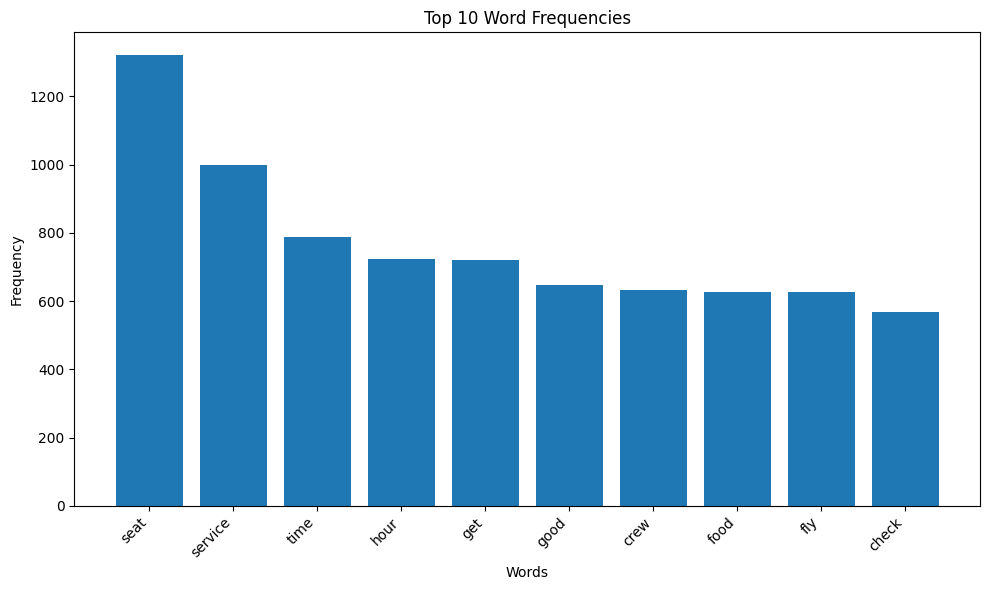

In [ ]:
# create a bar showing top 10 words sorted by counts descending

import matplotlib.pyplot as plt

word_freq = dtm.sum(axis=0)
word_freq_df = pd.DataFrame({'word': word_freq.index, 'count': word_freq.values}).sort_values(by='count', ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(word_freq_df['word'].head(10), word_freq_df['count'].head(10)) # change number in head() to control the top n
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 10 Word Frequencies")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


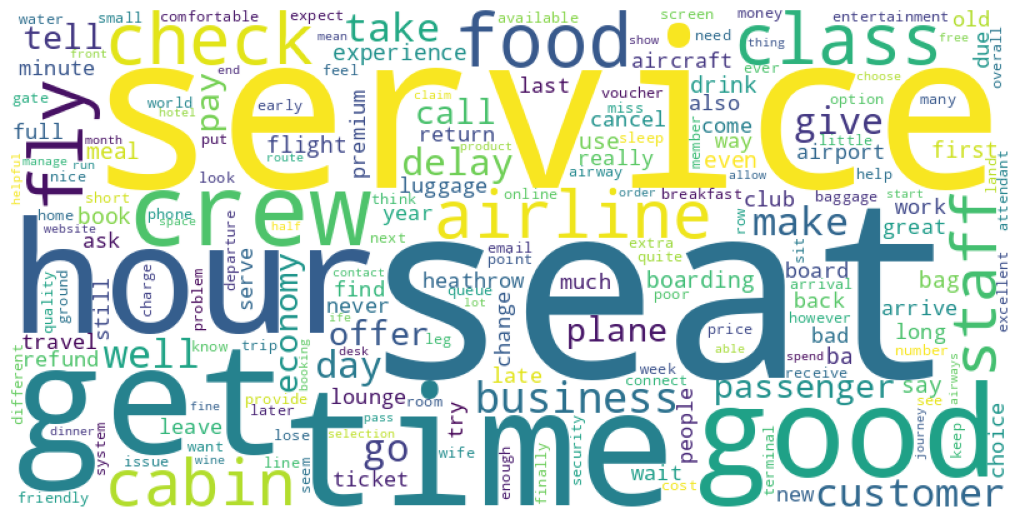

In [ ]:
# create a wordcloud with countvectoriser results
from wordcloud import WordCloud
import matplotlib.pyplot as plt

word_freq = dtm.sum(axis=0)  # Sum word counts across all documents

# create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

# display the generated image
plt.figure(figsize=(10, 5), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [ ]:
# We can use the same process to creat document term matrix by considering the importance of the words
# Here we will use TfidfVectorizer() from scikit-learn to convert a collection of raw documents to a matrix of TF-IDF features.
from sklearn.feature_extraction.text import TfidfVectorizer

# set vectorizer - CountVectorizer for word counts
tfidfvectorizer = TfidfVectorizer()

# create an array of word counts
vec = tfidfvectorizer.fit_transform(df.cleaned_review)

# convert this to a dataframe
tfidf = pd.DataFrame(vec.toarray(), columns=tfidfvectorizer.get_feature_names_out())

# set a threshold to drop infrequent words. here we set overall mean as the threshold. you can change the threshold to control the number of terms
threshold = tfidf.mean().mean()

# drop words based on the threshold
tfidf = tfidf.drop(tfidf.mean()[tfidf.mean() < threshold].index.values, axis=1) # Here find out the word with average word count lower than the threshold and drop them

# join the two datasets together
# tfidf = df.join(tfidf, how='left')

tfidf.head()

,able,absolute,absolutely,abysmal,accept,acceptable,access,accommodate,accommodation,accord,...,working,world,worst,worth,write,wrong,year,yesterday,yet,young
0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.10598,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# create a list of words sorted by tfidf score descending
word_tfidf = tfidf.sum(axis=0)
word_tfidf_df = pd.DataFrame({'word': word_tfidf.index, 'tfidf': word_tfidf.values})
word_tfidf_df = word_tfidf_df.sort_values(by='tfidf', ascending=False)
word_tfidf_df.head(10) # change number in head() to control the top n

,word,tfidf
859,seat,62.873130
875,service,47.083031
430,good,41.152966
465,hour,40.431497
1004,time,40.200169
237,crew,37.962101
399,food,37.329010
424,get,36.524835
180,class,36.108896
396,fly,35.697041


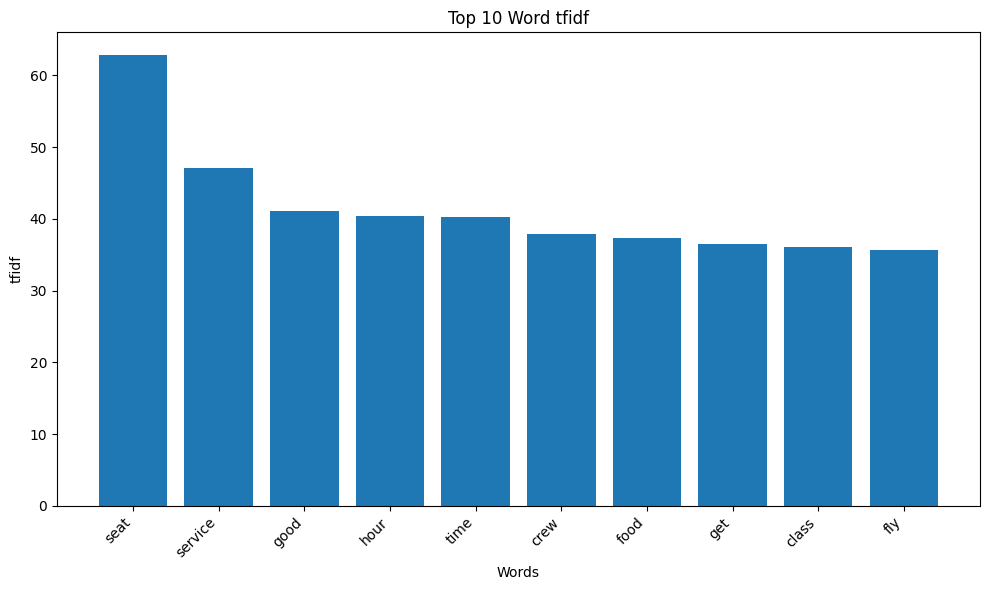

In [ ]:
# create a bar showing top 10 words sorted by counts descending

import matplotlib.pyplot as plt

word_tfidf = tfidf.sum(axis=0)
word_tfidf_df = pd.DataFrame({'word': word_tfidf.index, 'tfidf': word_tfidf.values}).sort_values(by='tfidf', ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(word_tfidf_df['word'].head(10), word_tfidf_df['tfidf'].head(10)) # change number in head() to control the top n
plt.xlabel("Words")
plt.ylabel("tfidf")
plt.title("Top 10 Word tfidf")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

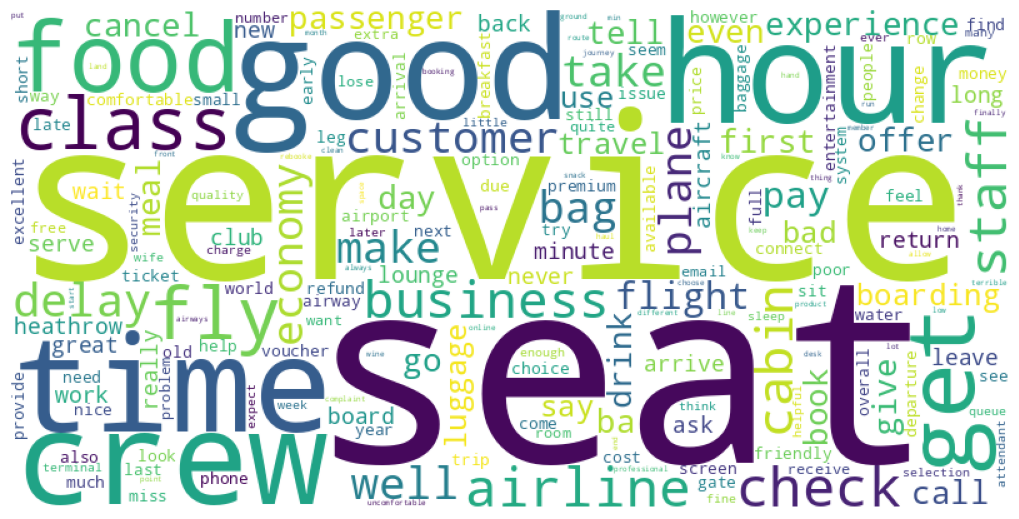

In [ ]:
# create a wordcloud with tfidfvectoriser results
from wordcloud import WordCloud
import matplotlib.pyplot as plt

word_tfidf = tfidf.sum(axis=0)  # Sum tfidf across all documents

# create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_tfidf)

# Display the generated image:
plt.figure(figsize=(10, 5), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

# **4. Topic Modelling with LDA**

Latent Dirichlet Allocation (LDA) is a classic model to do topic modelling. Topic modeling is unsupervised learning and the goal is to group different documents to the same “topic”.

In [ ]:
# vectorise the data into word counts

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA

# this limits the vocabulary size to the 1000 most frequent words, potentially improving efficiency.
max_words = 1000 # you can adjust the size based on your data size
vectorizer = CountVectorizer(max_features=max_words)
# vectorizer = CountVectorizer()
vec = vectorizer.fit_transform(df['cleaned_review'])

k = 4 #this is the number of the topic. you can decide the number

lda = LDA(n_components=k, learning_method='online', random_state = 42)
lda.fit(vec)

LatentDirichletAllocation(learning_method='online', n_components=4,
                          random_state=42)

Topic#  1
seat,good,crew,food,service,cabin,time,well,class,drink,meal,passenger,check,staff,boarding,first,economy,business,offer,fly,experience,lounge,serve,take,club,hour,aircraft,board,small,use,get,long,friendly,make,comfortable,plane,really,airline,entertainment,leg,full,ba,old,great,breakfast,flight,also,seem,nice,even

Topic#  2
customer,airline,travel,service,bag,refund,ticket,make,issue,cancel,luggage,fly,pay,book,cost,go,never,airway,experience,take,use,time,delay,change,even,bad,lose,money,explain,rude,week,rebooke,last,also,get,baggage,year,receive,ever,call,find,staff,hand,request,policy,due,put,happen,hour,extremely

Topic#  3
hour,get,tell,day,call,check,delay,time,airport,go,arrive,say,cancel,service,staff,give,customer,wait,bag,fly,book,find,try,take,plane,due,miss,minute,flight,number,heathrow,phone,make,luggage,back,airline,ask,voucher,next,offer,connect,late,help,leave,desk,finally,still,return,later,people

Topic#  4
seat,business,class,pay,fly,get,service,airline

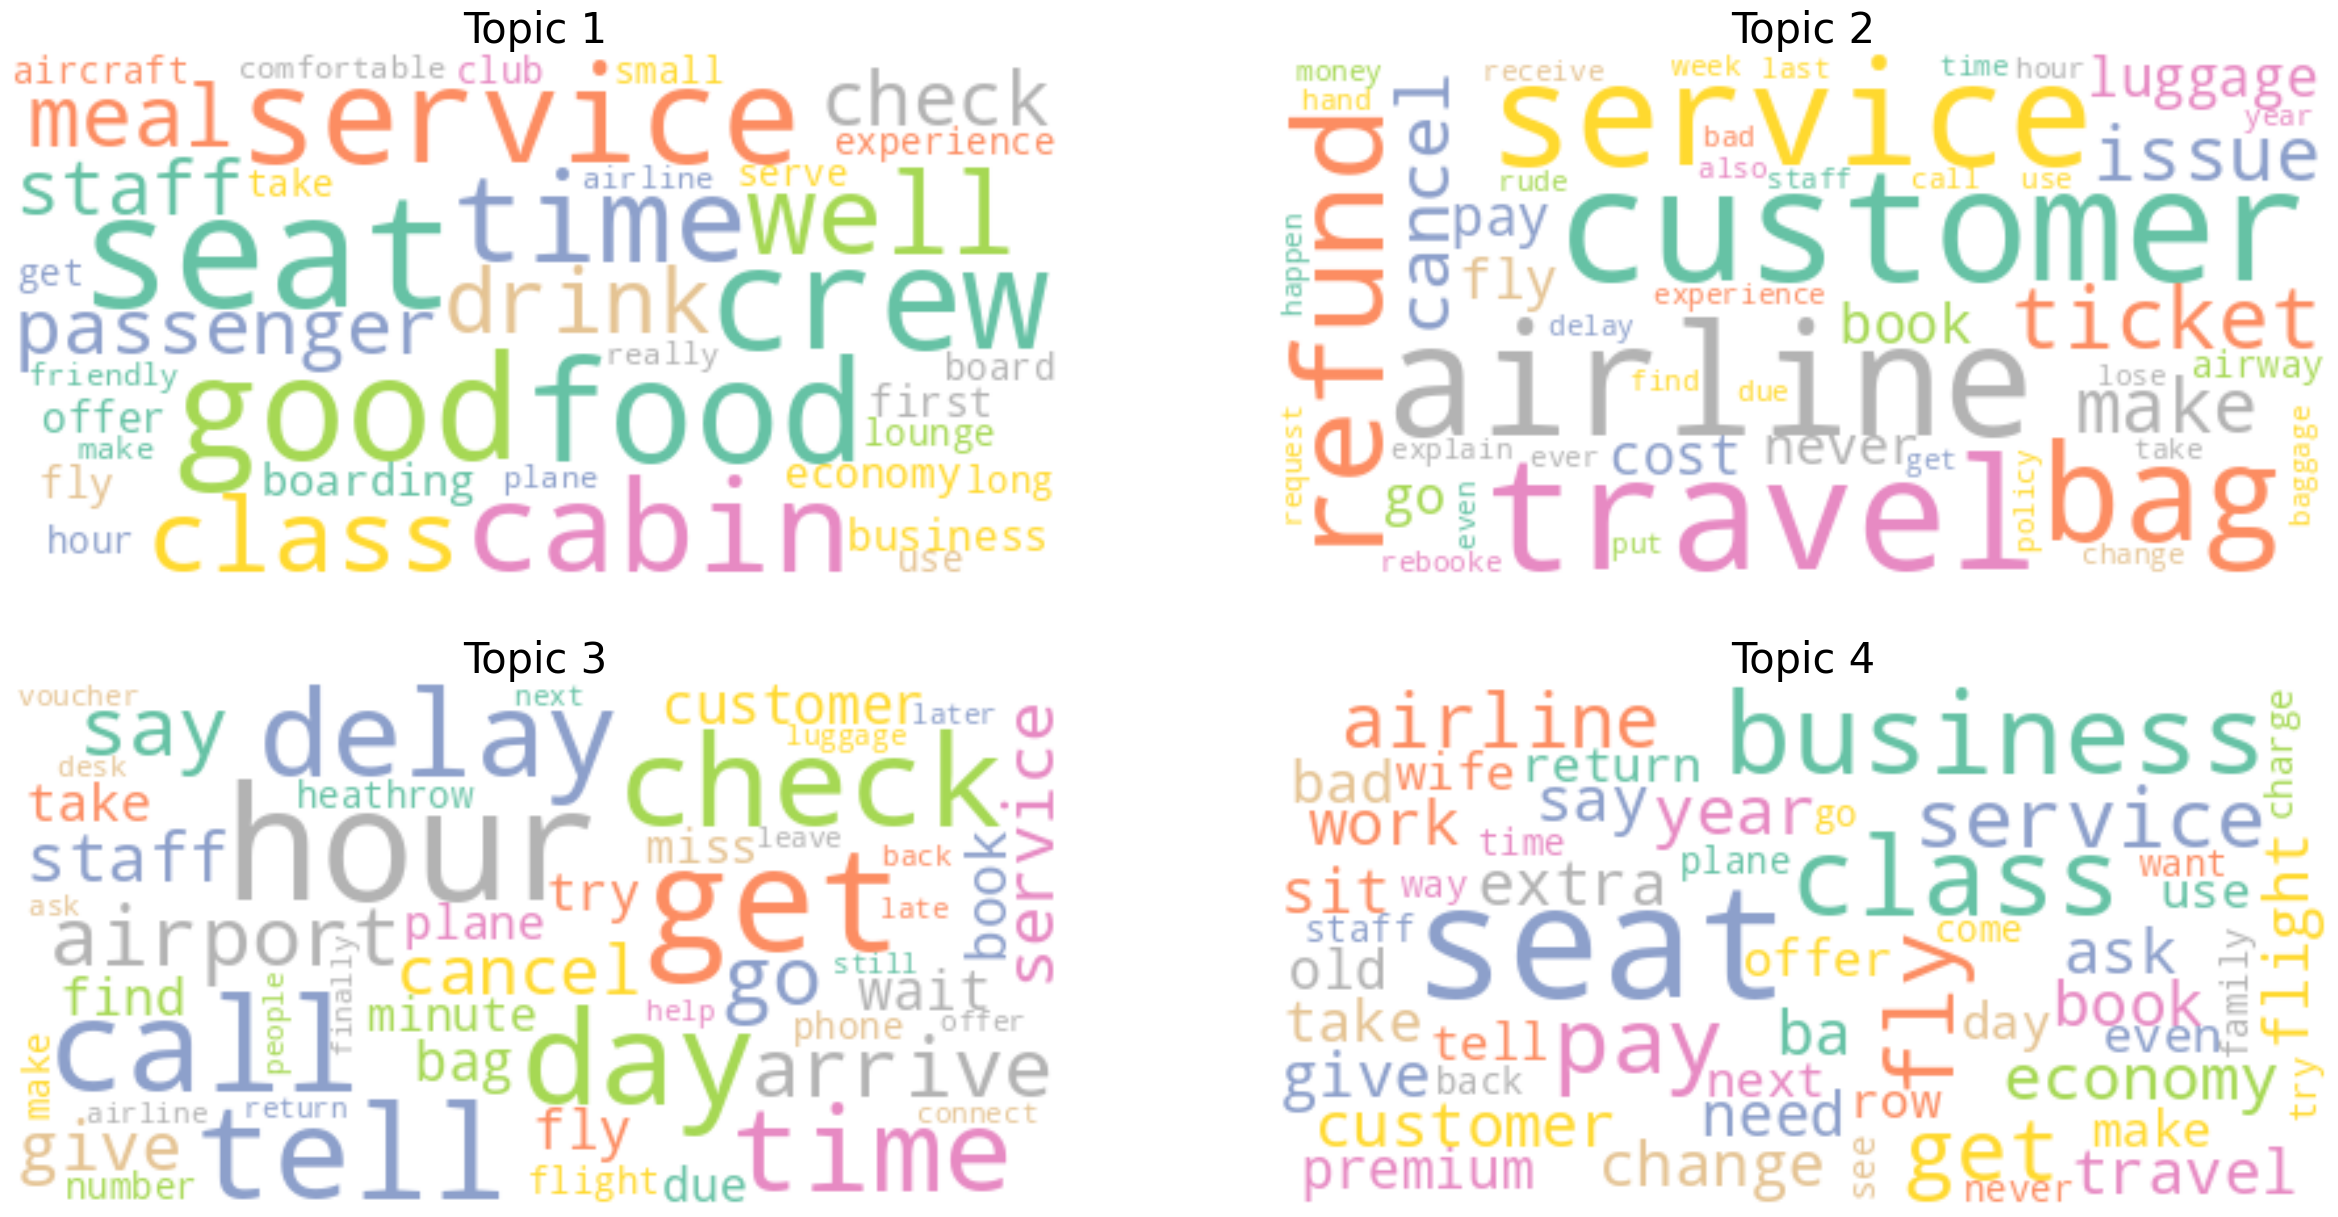

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import wordcloud

#declaring number of terms we need per topic
terms_count = 50

terms = vectorizer.get_feature_names_out()

wcloud = wordcloud.WordCloud(background_color="White",mask=None, max_words=100,\
                             max_font_size=60,min_font_size=10,prefer_horizontal=0.9,
                             contour_width=3,contour_color='Black',colormap='Set2')

fig, axes = plt.subplots(2, 2, figsize=(30, 15), sharex=True) # adjust your subplots based on how many topics you are generating.
axes = axes.flatten()

for idx,topic in enumerate(lda.components_):
    print('Topic# ',idx+1)
    abs_topic = abs(topic)
    topic_terms = [[terms[i],topic[i]] for i in abs_topic.argsort()[:-terms_count-1:-1]]
    topic_terms_sorted = [[terms[i], topic[i]] for i in abs_topic.argsort()[:-terms_count - 1:-1]]
    topic_words = []
    for i in range(terms_count):
        topic_words.append(topic_terms_sorted[i][0])
    print(','.join( word for word in topic_words))
    print("")
    dict_word_frequency = {}

    for i in range(terms_count):
        dict_word_frequency[topic_terms_sorted[i][0]] = topic_terms_sorted[i][1]

    ax = axes[idx]
    ax.set_title(f'Topic {idx +1}',fontdict={'fontsize': 30})
    wcloud.generate_from_frequencies(dict_word_frequency)
    ax.imshow(wcloud, interpolation='bilinear')
    ax.axis("off")

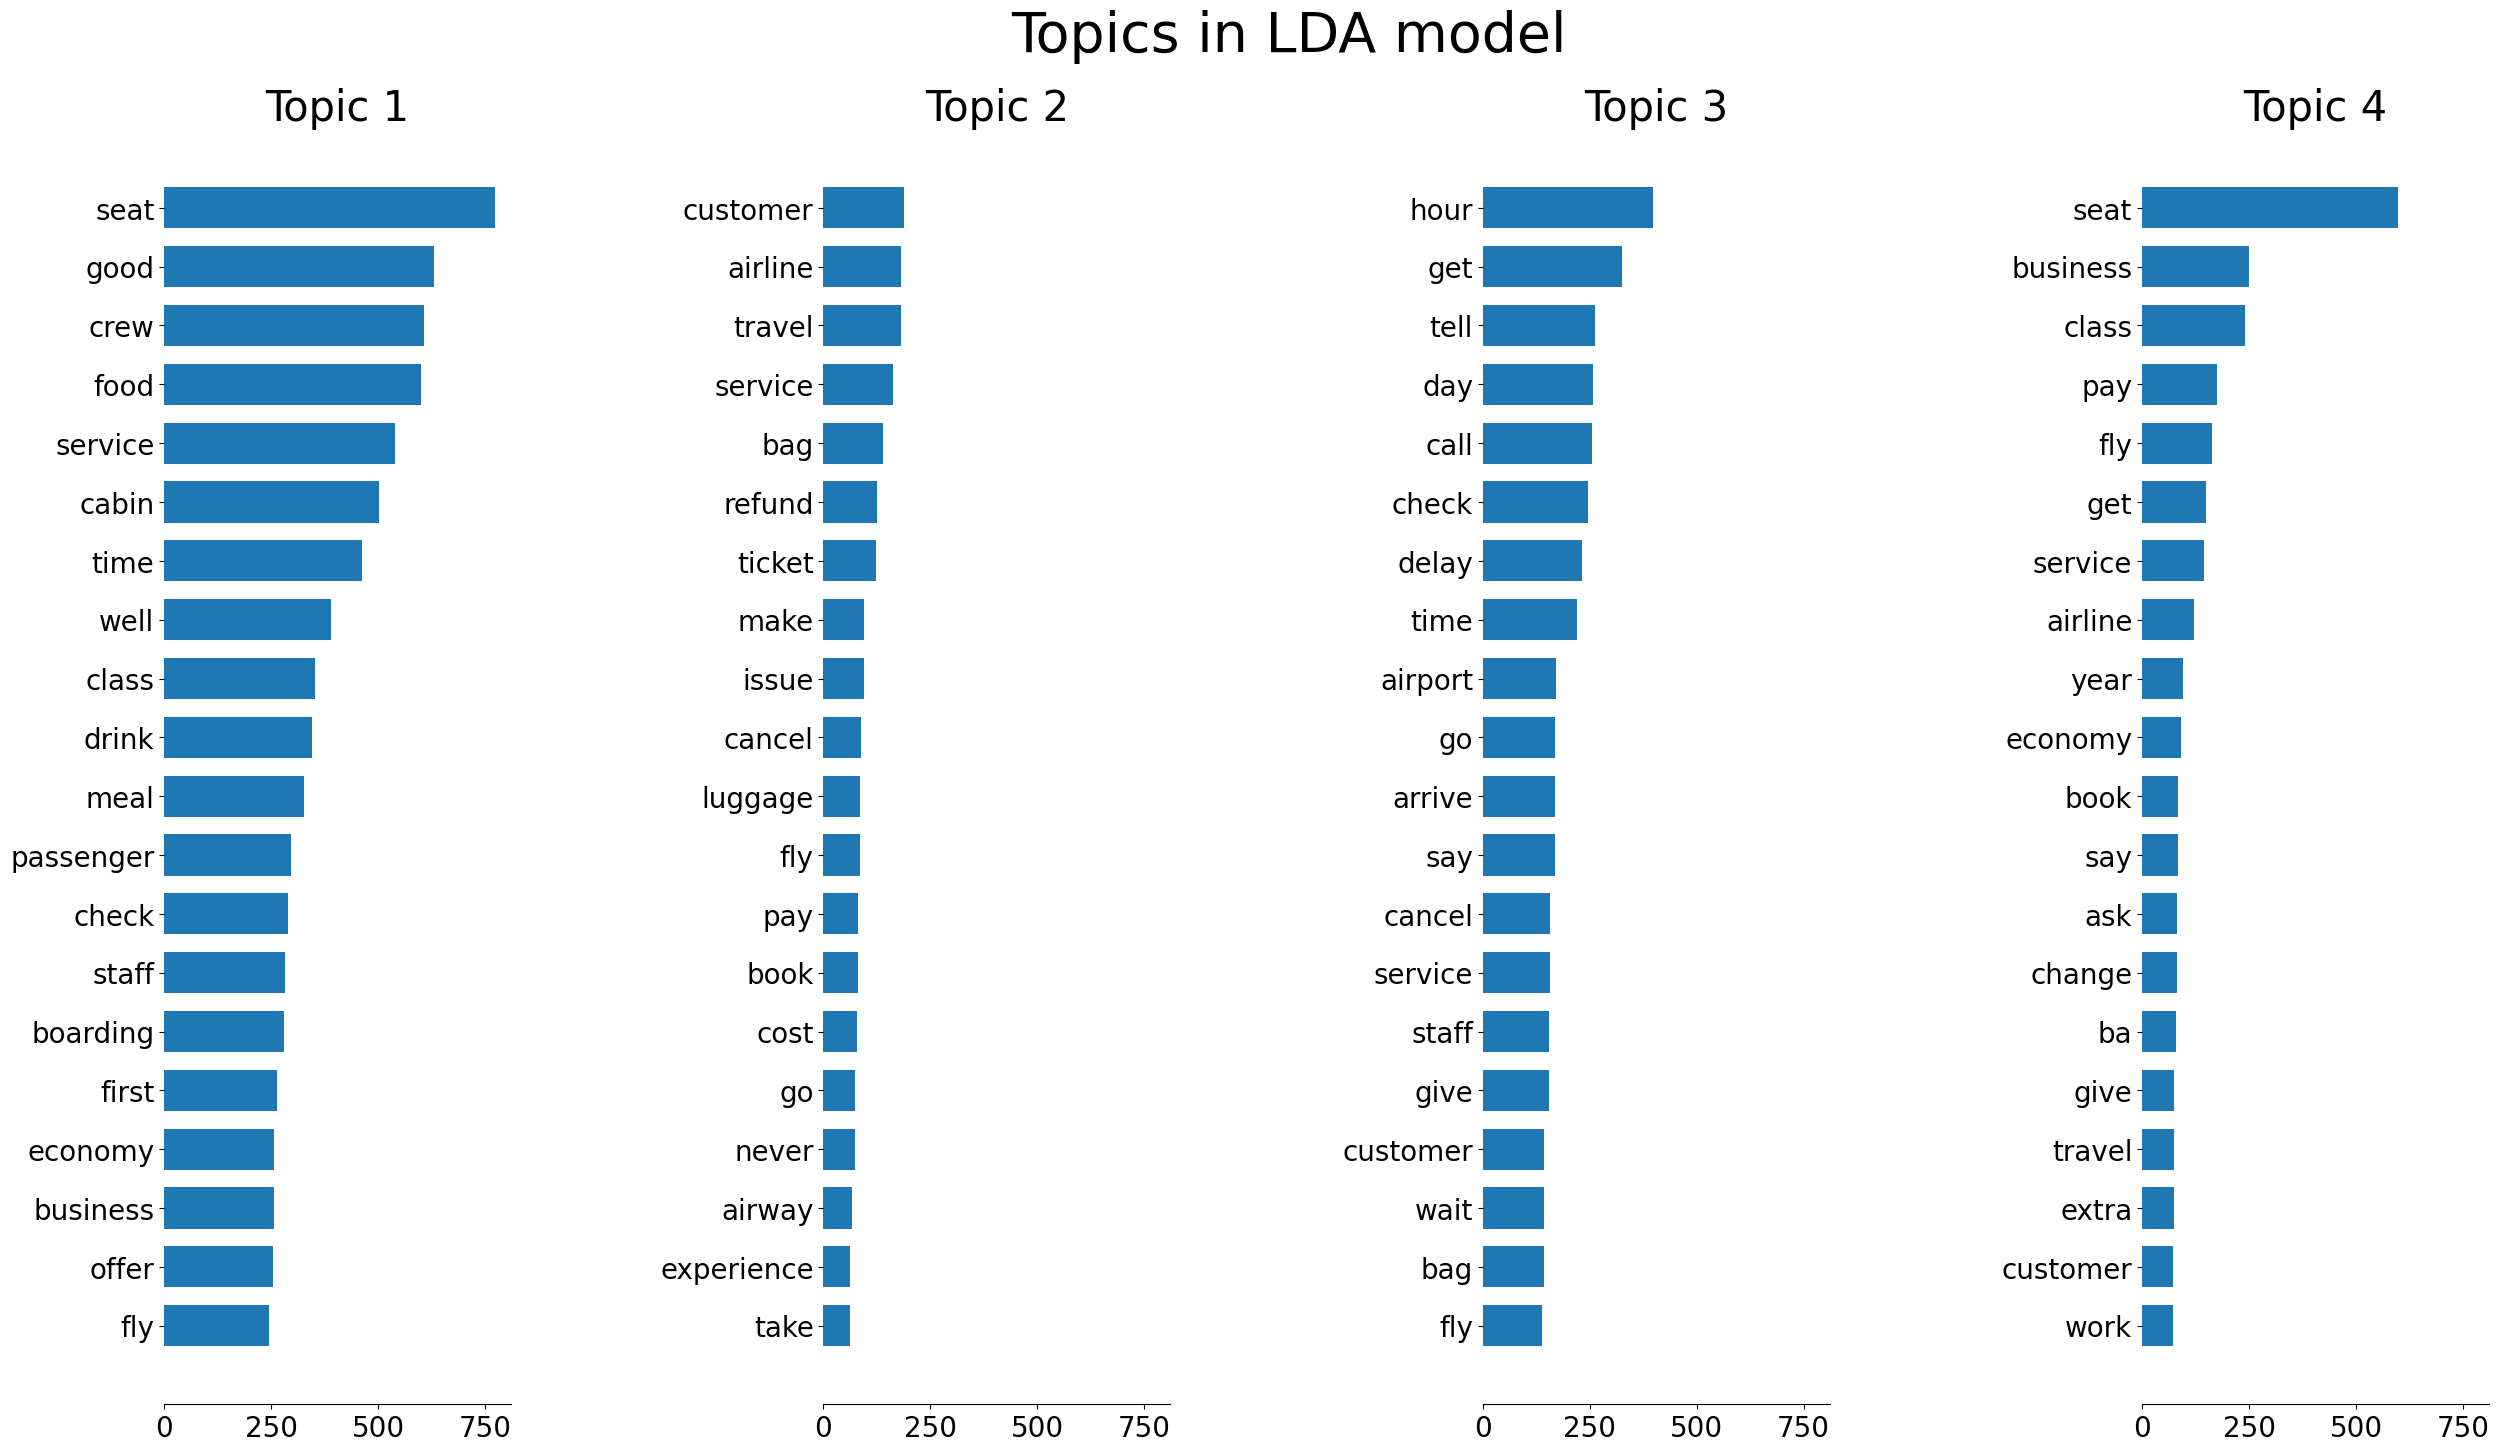

In [ ]:
# Visualise the result into bar charts in topic

%matplotlib inline
import matplotlib.pyplot as plt

# helper function to plot topics
# see Grisel et al.
# https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html
def plot_top_words(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(1, 4, figsize=(30, 15), sharex=True) # Here you change the structure of the plot; first number is row and second number is column
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f'Topic {topic_idx +1}',
                     fontdict={'fontsize': 30})
        ax.invert_yaxis()
        ax.tick_params(axis='both', which='major', labelsize=20)
        for i in 'top right left'.split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

n_top_words = 20  #how many words to be visualised in each topic

# get the list of words (feature names)
vec_feature_names = vectorizer.get_feature_names_out() # Make sure you set the right vectorizer name

# print the top words per topic
plot_top_words(lda, vec_feature_names, n_top_words, 'Topics in LDA model') # Make sure you set the right lda model name

# **5. Topic Modelling with BERTopic**

BERTopic can be also used for finding hidden topic in documents. BERTopic is built on BERT (Bidirectional Encoder Representations from Transformers), which creates contextual embeddings that capture deeper semantic meaning than traditional methods.

In [ ]:
# You need to install the package before using it
!pip install bertopic

In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic.representation import KeyBERTInspired
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

# Embedding model - choose a faster transformer model
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')  # This is faster than larger models

# Dimension reduction - keep the default
# umap_model = UMAP(n_neighbors=2, n_components=3, min_dist=0.05)

# Clustering - can also use to control number of topics
hdbscan_model = HDBSCAN(min_cluster_size=30, # A higher min_cluster_size will generate fewer topics and a lower min_cluster_size will generate more topics.
                        prediction_data=True) # This keeps additional data that allows assigning new documents to existing clusters later, which is useful if you want to classify new documents without retraining.


# Vectorizer - use a custom CountVectorizer with n-grams
stopwords = list(stopwords.words('english'))+ ['airline']
vectorizer = CountVectorizer(ngram_range=(1, 2),  # Include both unigrams and bigrams
                             stop_words=stopwords, # control the stop_words
                             min_df=5)  # Only include terms that appear in at least 5 documents

# c-TF-IDF - keep the default

# Fine-tune representation model
representation_model = KeyBERTInspired()


# Create a BERTopic model
topic_model = BERTopic(
    hdbscan_model=hdbscan_model,
    embedding_model=embedding_model,
    vectorizer_model=vectorizer,
    representation_model=representation_model,
    top_n_words=10,
    language='english',
    calculate_probabilities=True,
    verbose=True
)

# Fit the model to the cleaned reviews
topics, probs = topic_model.fit_transform(df['cleaned_review'])

# Check the documentation for more guidance on hyperparameter tuning: https://maartengr.github.io/BERTopic/getting_started/parameter%20tuning/parametertuning.html


In [ ]:
# Print the topics
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,566,-1_boarding_airport_cabin crew_flight,"[boarding, airport, cabin crew, flight, heathr...",[service go notably downhill past couple year ...
1,0,486,0_cabin crew_boarding_cabin_business class,"[cabin crew, boarding, cabin, business class, ...",[business class fly long time plane old wear d...
2,1,97,1_refund_customer service_cancel_booking,"[refund, customer service, cancel, booking, co...",[book website round trip flight stop first del...
3,2,76,2_customer service_delay hour_airport_flight,"[customer service, delay hour, airport, flight...",[absolutely bad experience ever fly heathrow p...
4,3,44,3_baggage_customer service_airport_fly,"[baggage, customer service, airport, fly, flig...",[today friend fly apparently go well check ine...
5,4,31,4_booking_reservation_seat selection_seat avai...,"[booking, reservation, seat selection, seat av...",[book wife premium economy use frequent flyer ...


When using HDBSCAN, topic -1 contains all documents that couldn't be confidently assigned to any specific cluster. Having
reviews classified as outliers suggests a few possibilities:

- High diversity in your reviews: the reviews might cover many different topics with little overlap, making it difficult for the algorithm to find clear clusters.

- Noise in the data: If the reviews are short or contain unusual language patterns, they might be harder to cluster effectively.

In [ ]:
topic_model.visualize_barchart(n_words=10, height=300)

In [ ]:
topic_model.visualize_topics()

In [ ]:
# Add the topics back to our dataframe
df['topic'] = topics

In [ ]:
df.head()

,title,reviews,published_dates,user_name,user_location,user_ratings,trip_details,would_recommed_to_others,cleaned_review,topic
0,“Worst service ever”,worst service ever lost baggage because of de...,23rd January 2024,Chirag Thummar,Germany,1,Type Of TravellerSolo Leisure\nSeat TypeEconom...,n,bad service ever lose baggage delay miss conne...,3
1,"""unprofessional attitude of the pilots""",ba jan did not appreciate the unprofessional ...,21st January 2024,D Carreno,United Kingdom,6,AircraftA350\nType Of TravellerBusiness\nSeat ...,n,appreciate unprofessional attitude pilot sched...,-1
2,“Next time it will be Jet2”,not a great experience i could not check in o...,18th January 2024,Simon Channon,United Kingdom,3,AircraftA320\nType Of TravellerCouple Leisure\...,n,great experience check online separate part co...,-1
3,“become the Ryanair of long-haul travel”,i was excited to fly ba as i would not travel...,18th January 2024,Melissa Harris,United Kingdom,2,Type Of TravellerFamily Leisure\nSeat TypeEcon...,n,excited fly ba travel long travel many occasio...,0
4,“They never help us”,i just want to warn everyone of the worst cus...,17th January 2024,Ivana Squassabia,Germany,1,Type Of TravellerFamily Leisure\nSeat TypeBusi...,n,want warn bad customer service experience ever...,-1


# Check more NLP techniques

- [Use TextBlob and NLTK for sentiment analysis](https://colab.research.google.com/drive/1awgFrFAEi19XPWRsT_rebySoDewYF-j0?usp=sharing)
- [Connect with Google Natural Language API to do sentiment analysis](https://colab.research.google.com/drive/1Rqr3rrQUh4Rd4SQCmPWcWzqfjtIUKWwA?usp=sharing)